# Infraslow sigma-power oscillation — grand average from precomputed metrics (N2 / N3 / NREM)

Reads `results_tmp/all_metrics.csv` (per-subject ISFS metrics produced by
`src/run_all_metrics.py` / `infraslow.processing.all_metrics`, the same Fig C-i
Gaussian fit as `demo_infraslow_yasa_average.ipynb`) and reproduces that notebook's
grand-average plot for all three infraslow stage groups (**N2**, **N3**, **NREM**)
— but starting from the already-fitted per-subject parameters instead of raw EDFs.

For each subject and stage, `all_metrics.csv` stores the Fig C-i Gaussian fit
(`amp * exp(-0.5*((f-mu)/sd)**2)`) as three numbers: `fit_peak_freq` (mu),
`bandwidth_hz` (`2*sd`) and `auc` (area under the curve over the fitted +/-1 SD
window). Since `auc = amp * sd * sqrt(2*pi) * erf(1/sqrt(2))` for that window,
`amp` is recovered algebraically from `auc` and `sd`, so each subject's fitted
curve can be evaluated on a common frequency grid and averaged across subjects
(mean +/- SEM) — the same grand-average step the reference notebook does on raw
relative spectra.

In [1]:
from math import erf, pi, sqrt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from infraslow.processing.all_metrics import INFRASLOW_BAND, INFRASLOW_STAGES

plt.rcParams['figure.dpi'] = 110
STAGE_COLORS = {'N2': '#5b2a86', 'N3': '#1f77b4', 'NREM': '#2ca02c'}

## Load precomputed metrics

In [2]:
RESULTS_CSV = Path('../results_tmp/all_metrics.csv')
metrics = pd.read_csv(RESULTS_CSV)
print(f"{len(metrics)} subjects in {RESULTS_CSV}")

preview_cols = ['ID'] + [
    f'{stage}_{key}'
    for stage in INFRASLOW_STAGES
    for key in ('fit_peak_freq', 'bandwidth_hz', 'auc', 'detected')
]
metrics[preview_cols].head()

46804 subjects in ../results_tmp/all_metrics.csv


/tmp/ipykernel_3834/1884677138.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  metrics = pd.read_csv(RESULTS_CSV)


,ID,N2_fit_peak_freq,N2_bandwidth_hz,N2_auc,N2_detected,N3_fit_peak_freq,N3_bandwidth_hz,N3_auc,N3_detected,NREM_fit_peak_freq,NREM_bandwidth_hz,NREM_auc,NREM_detected
0,{BCDDD1AE-F41D-41A9-9626-7DCF98107279},0.026431,0.038406,0.188807,True,0.021167,0.011750,0.085487,True,0.025395,0.039841,0.188071,True
1,{9E64BABE-51FD-4E92-8E3B-61D73382C35F},0.030071,0.033142,0.420131,True,NaN,NaN,NaN,False,0.027924,0.033284,0.374131,True
2,{4ADD7F52-EA02-46E4-B214-0EDF3EAB1D7D},0.032164,0.017702,0.129790,True,NaN,NaN,NaN,False,0.028662,0.026504,0.200904,True
3,{3A8B7904-473F-4DE3-AEB4-93161DCF4E4A},0.029163,0.016432,0.051878,True,0.015367,0.005279,0.334393,True,0.029926,0.021226,0.094175,True
4,{FAAA956D-AB81-4B90-BCAE-C6FE926CF325},0.022087,0.037941,0.219669,True,0.017765,0.013157,0.132400,True,0.021842,0.030143,0.231446,True


## Reconstruct each subject's fitted infraslow curve

`amp = auc / (sd * _PM1SD_FACTOR)`, where `_PM1SD_FACTOR` is the closed-form
integral of a unit Gaussian over +/-1 SD (`sqrt(2*pi) * erf(1/sqrt(2))`) — the
same window `_fit_isfs` integrates over when it computes `auc`. Only subjects
with a complete, finite `(fit_peak_freq, bandwidth_hz, auc)` triple for a stage
(i.e. the aggregate Gaussian fit converged) contribute a curve for that stage;
this mirrors the reference notebook only averaging subjects with usable bouts.

In [3]:
def _gaussian(f, amp, mu, sd):
    return amp * np.exp(-0.5 * ((f - mu) / sd) ** 2)

_PM1SD_FACTOR = sqrt(2 * pi) * erf(1 / sqrt(2))  # unit-Gaussian area over +/-1 SD
FREQ_GRID = np.linspace(*INFRASLOW_BAND, 400)


def stage_curves(metrics: pd.DataFrame, stage: str) -> tuple[np.ndarray, pd.DataFrame]:
    """Per-subject fitted infraslow curves for `stage`, evaluated on FREQ_GRID.

    The returned table also carries `{stage}_peak_freq` -- the *empirical* argmax
    peak (the "real" peak) -- alongside the Gaussian-fit inputs, on the same
    usable-fit subject set, so fit vs. real peak stats are directly comparable.
    """
    fit_cols = [f'{stage}_fit_peak_freq', f'{stage}_bandwidth_hz', f'{stage}_auc']
    extra_cols = [f'{stage}_peak_freq', f'{stage}_detected']
    sub = metrics[['ID'] + fit_cols + extra_cols].dropna(subset=fit_cols)
    mu = sub[f'{stage}_fit_peak_freq'].to_numpy()
    sd = sub[f'{stage}_bandwidth_hz'].to_numpy() / 2.0
    amp = sub[f'{stage}_auc'].to_numpy() / (sd * _PM1SD_FACTOR)
    curves = np.stack([_gaussian(FREQ_GRID, a, m, s) for a, m, s in zip(amp, mu, sd)])
    return curves, sub


stage_curve_arrays, stage_fit_tables = {}, {}
for stage in INFRASLOW_STAGES:
    curves, sub = stage_curves(metrics, stage)
    stage_curve_arrays[stage] = curves
    stage_fit_tables[stage] = sub
    print(f'{stage}: {len(curves)}/{len(metrics)} subjects with a usable ISFS fit')

N2: 45131/46804 subjects with a usable ISFS fit
N3: 21020/46804 subjects with a usable ISFS fit
NREM: 45389/46804 subjects with a usable ISFS fit


## Grand average across subjects (mean +/- SEM)

In [4]:
grand = {}
for stage in INFRASLOW_STAGES:
    curves = stage_curve_arrays[stage]
    sub = stage_fit_tables[stage]
    n = len(curves)
    mean_curve = curves.mean(axis=0)
    sem_curve = curves.std(axis=0, ddof=1) / np.sqrt(n)
    peak_idx = int(np.argmax(mean_curve))
    real_peak = sub[f'{stage}_peak_freq']
    grand[stage] = dict(
        n=n, mean=mean_curve, sem=sem_curve,
        fit_peak_freq=FREQ_GRID[peak_idx], fit_peak_power=mean_curve[peak_idx],
        real_peak_freq_mean=real_peak.mean(), real_peak_freq_sem=real_peak.sem(),
    )
    g = grand[stage]
    print(f"{stage}: fit peak {g['fit_peak_freq']:.4f} Hz (~{1 / g['fit_peak_freq']:.0f} s) | "
          f"real peak {g['real_peak_freq_mean']:.4f} Hz "
          f"(~{1 / g['real_peak_freq_mean']:.0f} s), n={n}")

N2: fit peak 0.0253 Hz (~39 s) | real peak 0.0262 Hz (~38 s), n=45131
N3: fit peak 0.0159 Hz (~63 s) | real peak 0.0244 Hz (~41 s), n=21020
NREM: fit peak 0.0249 Hz (~40 s) | real peak 0.0255 Hz (~39 s), n=45389


### Real (empirical) peak

Grand-average curve per stage with the mean **empirical argmax** peak frequency
(across subjects) marked -- no Gaussian fit involved.

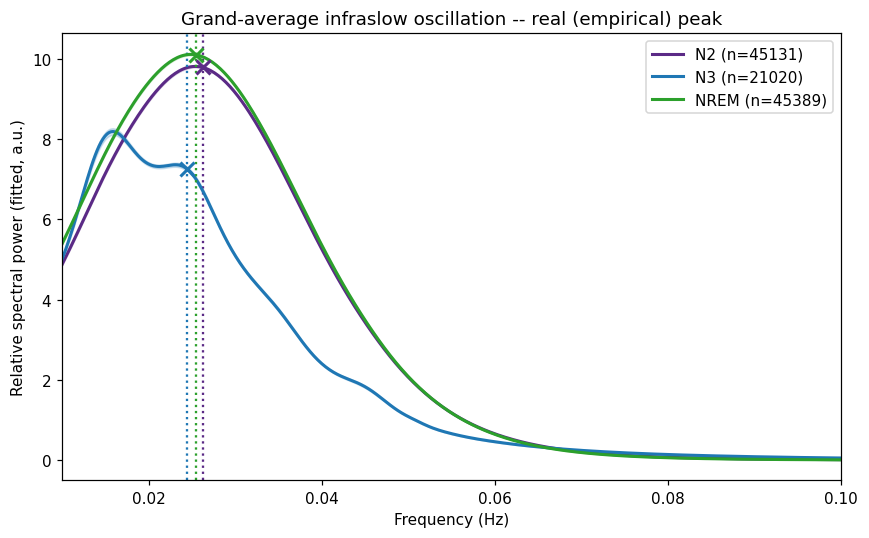

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for stage in INFRASLOW_STAGES:
    g = grand[stage]
    color = STAGE_COLORS[stage]
    ax.plot(FREQ_GRID, g['mean'], color=color, lw=2, label=f'{stage} (n={g["n"]})')
    ax.fill_between(FREQ_GRID, g['mean'] - g['sem'], g['mean'] + g['sem'],
                     color=color, alpha=0.2)
    real_peak = g['real_peak_freq_mean']
    ax.axvline(real_peak, color=color, lw=1.5, ls=':')
    ax.plot([real_peak], [np.interp(real_peak, FREQ_GRID, g['mean'])],
            'x', color=color, ms=9, mew=2, zorder=5)

ax.set(xlim=INFRASLOW_BAND, xlabel='Frequency (Hz)',
       ylabel='Relative spectral power (fitted, a.u.)',
       title='Grand-average infraslow oscillation -- real (empirical) peak')
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

### Fit peak + area under curve (AUC)

Same grand-average curves with the Gaussian-fit peak (mu) marked and the AUC
region (+/-1 SD around the mean bandwidth) shaded, matching Fig C-i of the
reference notebook. The legend reports each stage's mean per-subject AUC.

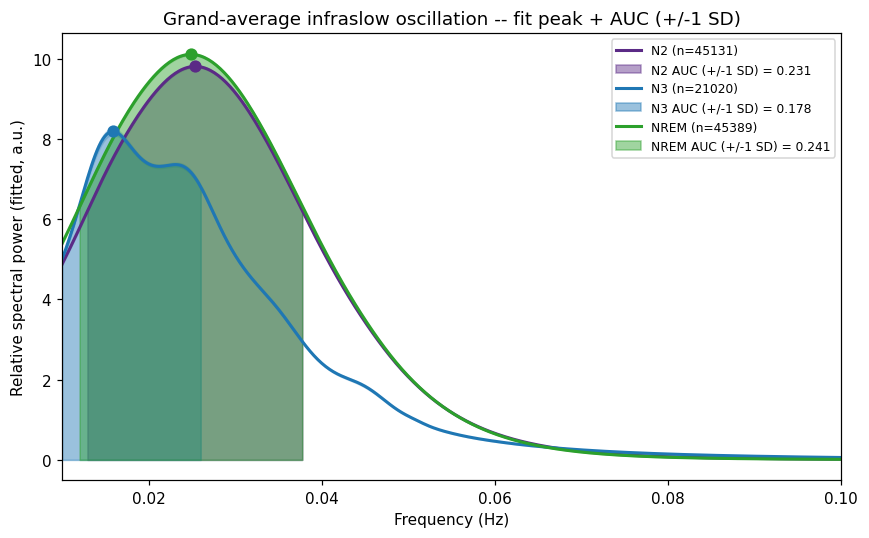

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for stage in INFRASLOW_STAGES:
    g = grand[stage]
    sub = stage_fit_tables[stage]
    color = STAGE_COLORS[stage]
    ax.plot(FREQ_GRID, g['mean'], color=color, lw=2, label=f'{stage} (n={g["n"]})')
    ax.fill_between(FREQ_GRID, g['mean'] - g['sem'], g['mean'] + g['sem'],
                     color=color, alpha=0.2)

    mu = g['fit_peak_freq']
    sd = sub[f'{stage}_bandwidth_hz'].mean() / 2.0
    auc_mean = sub[f'{stage}_auc'].mean()
    lo, hi = mu - sd, mu + sd
    auc_m = (FREQ_GRID >= lo) & (FREQ_GRID <= hi)
    ax.fill_between(FREQ_GRID[auc_m], g['mean'][auc_m], color=color, alpha=0.45,
                     label=f'{stage} AUC (+/-1 SD) = {auc_mean:.3g}')
    ax.plot([mu], [g['fit_peak_power']], 'o', color=color, ms=7, zorder=5)

ax.set(xlim=INFRASLOW_BAND, xlabel='Frequency (Hz)',
       ylabel='Relative spectral power (fitted, a.u.)',
       title='Grand-average infraslow oscillation -- fit peak + AUC (+/-1 SD)')
ax.legend(frameon=True, fontsize=8)
fig.tight_layout()
plt.show()

## Analysis data — per-stage ISFS summary across the cohort

Mean +/- SEM of the stored per-subject fit parameters (not the reconstructed
curves) for each stage, plus the ISFS detection rate and average N2/N3/NREM
bout burden — the same summary `demo_infraslow_yasa_average.ipynb` builds per
subject in its last section, aggregated here across the whole `all_metrics.csv`
cohort.

In [7]:
def stage_summary(metrics: pd.DataFrame, stage: str) -> dict:
    detected = metrics[f'{stage}_detected'] == True  # noqa: E712 - pandas bool column
    cols = [f'{stage}_peak_freq', f'{stage}_fit_peak_freq', f'{stage}_bandwidth_hz', f'{stage}_auc']
    fit = metrics.loc[detected, cols]
    real_peak = fit[f'{stage}_peak_freq']
    fit_peak = fit[f'{stage}_fit_peak_freq']
    bandwidth, auc = fit[f'{stage}_bandwidth_hz'], fit[f'{stage}_auc']
    return {
        'stage': stage,
        'n_subjects': int(len(metrics)),
        'n_detected': int(detected.sum()),
        'detection_rate_%_mean': 100 * detected.mean(),
        'detection_rate_%_sem': 100 * detected.sem(),
        'real_peak_freq_hz_mean': real_peak.mean(), 'real_peak_freq_hz_sem': real_peak.sem(),
        'real_peak_period_s_mean': (1 / real_peak).mean(), 'real_peak_period_s_sem': (1 / real_peak).sem(),
        'fit_peak_freq_hz_mean': fit_peak.mean(), 'fit_peak_freq_hz_sem': fit_peak.sem(),
        'fit_peak_period_s_mean': (1 / fit_peak).mean(), 'fit_peak_period_s_sem': (1 / fit_peak).sem(),
        'bandwidth_hz_mean': bandwidth.mean(), 'bandwidth_hz_sem': bandwidth.sem(),
        'auc_mean': auc.mean(), 'auc_sem': auc.sem(),
        'bouts_min_mean': metrics[f'{stage}_bouts'].mean(),
        'bouts_min_sem': metrics[f'{stage}_bouts'].sem(),
        'percent_bouts_mean': metrics[f'{stage}_percent_bouts'].mean(),
        'percent_bouts_sem': metrics[f'{stage}_percent_bouts'].sem(),
    }


summary = pd.DataFrame([stage_summary(metrics, s) for s in INFRASLOW_STAGES]).set_index('stage')
summary.round(4)

,n_subjects,n_detected,detection_rate_%_mean,detection_rate_%_sem,real_peak_freq_hz_mean,real_peak_freq_hz_sem,real_peak_period_s_mean,real_peak_period_s_sem,fit_peak_freq_hz_mean,fit_peak_freq_hz_sem,fit_peak_period_s_mean,fit_peak_period_s_sem,bandwidth_hz_mean,bandwidth_hz_sem,auc_mean,auc_sem,bouts_min_mean,bouts_min_sem,percent_bouts_mean,percent_bouts_sem
stage,,,,,,,,,,,,,,,,,,,,
N2,46804,44503,95.0838,0.0999,0.0262,0.0000,39.8202,0.0408,0.0267,0.0000,39.1696,0.0422,0.0253,0.0000,0.2336,0.0005,158.2277,0.3377,48.0815,0.0628
N3,46804,18975,40.5414,0.2269,0.0237,0.0001,48.3493,0.1372,0.0240,0.0001,47.4910,0.1246,0.0211,0.0001,0.1948,0.0010,37.3963,0.1650,11.2654,0.0474
NREM,46804,44967,96.0751,0.0898,0.0254,0.0000,40.9473,0.0407,0.0261,0.0000,40.1014,0.0428,0.0260,0.0000,0.2430,0.0005,250.7603,0.4819,76.0358,0.0558


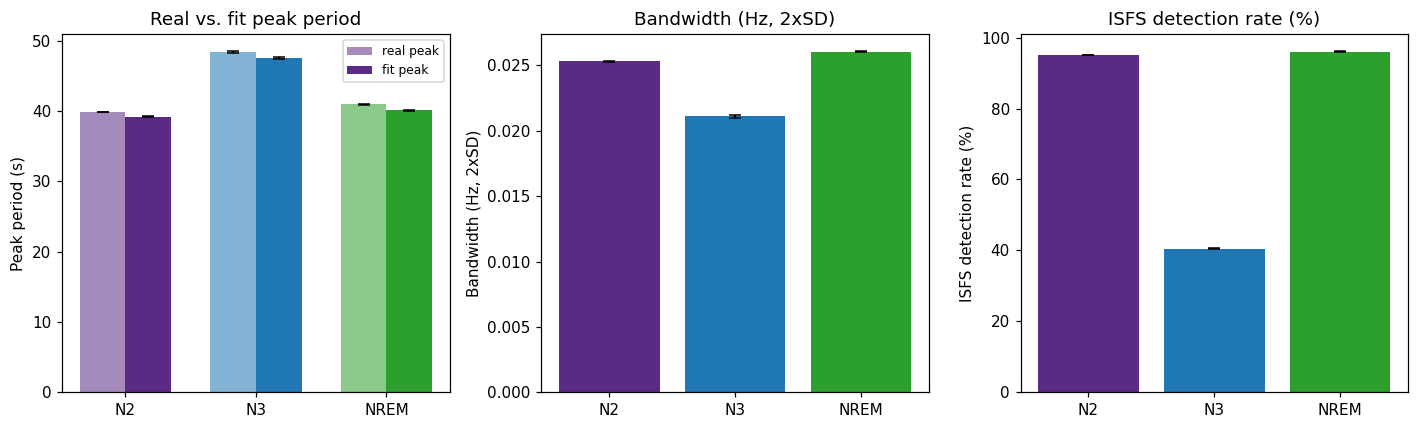

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax = axes[0]
width = 0.35
x = np.arange(len(summary))
ax.bar(x - width / 2, summary['real_peak_period_s_mean'], width,
       yerr=summary['real_peak_period_s_sem'], capsize=4, label='real peak',
       color=[STAGE_COLORS[s] for s in summary.index], alpha=0.55)
ax.bar(x + width / 2, summary['fit_peak_period_s_mean'], width,
       yerr=summary['fit_peak_period_s_sem'], capsize=4, label='fit peak',
       color=[STAGE_COLORS[s] for s in summary.index])
ax.set_xticks(x)
ax.set_xticklabels(summary.index)
ax.set(ylabel='Peak period (s)', title='Real vs. fit peak period')
ax.legend(fontsize=8)

for ax, col, ylabel in zip(axes[1:], ['bandwidth_hz', 'detection_rate_%'],
                            ['Bandwidth (Hz, 2xSD)', 'ISFS detection rate (%)']):
    vals, errs = summary[f'{col}_mean'], summary[f'{col}_sem']
    ax.bar(summary.index, vals, yerr=errs, capsize=4,
           color=[STAGE_COLORS[s] for s in summary.index])
    ax.set(ylabel=ylabel, title=ylabel)
fig.tight_layout()
plt.show()